In [21]:
import os, numpy as np, matplotlib.pyplot as plt, tensorflow as tf,sionna
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver, subcarrier_frequencies, RadioMapSolver
scene = load_scene(sionna.rt.scene.etoile)
# Configure arrays for all transmitters and receivers in the scene
scene.tx_array = PlanarArray(num_rows=4,num_cols=4,pattern="iso", polarization="V")
scene.rx_array = scene.tx_array

# Add a transmitter and a receiver
scene.add(Transmitter("tx", [-25,0.1,50]))
scene.add(Receiver("rx",    [ 25,0.1,50]))

# Compute paths
p_solver = PathSolver()
paths = p_solver(scene=scene, max_depth=5,
                       los=True,
                       specular_reflection=True,
                       diffuse_reflection=False,
                       refraction=False,
                       synthetic_array=False,
                       )

num_ofdm_symbols = 1024
num_subcarriers = 1024
subcarrier_spacing = 30e3

ofdm_symbol_duration = 1/subcarrier_spacing
delay_resolution = ofdm_symbol_duration/num_subcarriers
doppler_resolution = subcarrier_spacing/num_ofdm_symbols

print("Delay   resolution (ns): ", int(delay_resolution/1e-9))
print("Doppler resolution (Hz): ", int(doppler_resolution))
# Compute channel frequency response with time evolution
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

h = paths.cfr(frequencies=frequencies,
              sampling_frequency=1/ofdm_symbol_duration,
              num_time_steps=num_ofdm_symbols,
              normalize_delays=False, normalize=False, out_type="numpy")
print("Shape of channel frequency response: ", h.shape) #(1, 16, 1, 16, 1024, 1024)

Delay   resolution (ns):  32
Doppler resolution (Hz):  29
Shape of channel frequency response:  (1, 16, 1, 16, 1024, 1024)


paths.tau.shape = (1, 16, 1, 16, 6)
Delay - LoS Path (ns) : 865.181
Delay - Reflected Path (ns) : [ 865.1807  1657.7588   166.78204  373.3194  2268.783   1572.296  ]


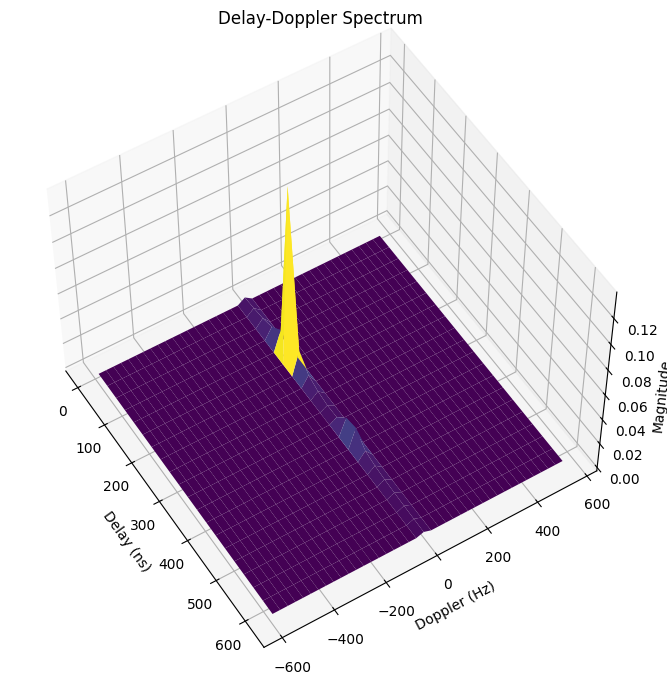

In [22]:



### Compute the Delay-Doppler spectrum
# Squeeze useless dimensions
# [num_time_steps, fft_size]
h_squeeze = h[0,0,0,0,:,:]

# Apply an FFTshift to bring subcarriers in the
# correct order for an IFFT
h_squeeze = np.fft.fftshift(h_squeeze, axes=1)

# Apply IFFT to subcarrier dimension to
# convert frequency to delay domain
h_delay = np.fft.ifft(h_squeeze, axis=1, norm="ortho")

# Apply FFT to time-step dimension to
# convert time to Doppler domain
h_delay_doppler = np.fft.fft(h_delay, axis=0, norm="ortho")

# Apply FFTShift to bring Doppler dimension in the correct
# order for visualization
h_delay_doppler = np.fft.fftshift(h_delay_doppler, axes=0)

# Compute meshgrid for visualization of the Delay-Doppler spectrum
doppler_bins = np.arange(-num_ofdm_symbols/2*doppler_resolution,
                          num_ofdm_symbols/2*doppler_resolution,
                         doppler_resolution)

delay_bins = np.arange(0,
                       num_subcarriers*delay_resolution,
                       delay_resolution) / 1e-9

x, y = np.meshgrid(delay_bins, doppler_bins)

# Visualize Delay-Doppler spectrum
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')

# We only visualize the relevant part of the spectrum
offset = 20
x_start = int(num_subcarriers/2)-offset
x_end = int(num_subcarriers/2)+offset
y_start = 0
y_end = offset
x_grid = x[x_start:x_end,y_start:y_end]
y_grid = y[x_start:x_end,y_start:y_end]
z_grid = np.abs(h_delay_doppler[x_start:x_end,y_start:y_end])

surf = ax.plot_surface(x_grid,
                       y_grid,
                       z_grid,
                       cmap='viridis', edgecolor='none')

ax.set_xlabel('Delay (ns)')
ax.set_ylabel('Doppler (Hz)')
ax.set_zlabel('Magnitude')
ax.zaxis.labelpad=2
ax.view_init(elev=53, azim=-32)
ax.set_title("Delay-Doppler Spectrum")
print("paths.tau.shape =",paths.tau.shape)

print("Delay - LoS Path (ns) :", paths.tau[0,0,0,0,0]/1e-9)

print("Delay - Reflected Path (ns) :", paths.tau[0,0,0,0,:].numpy()/1e-9)

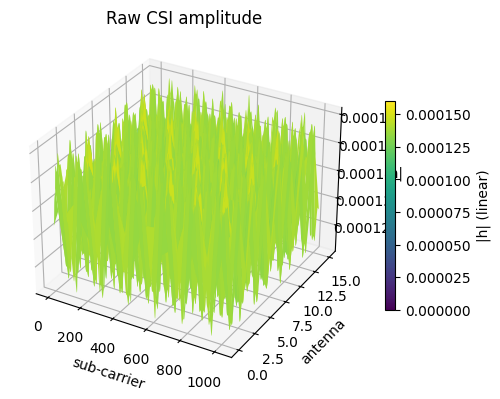

In [52]:
# --- pick one link: Rx ant 'all', any Tx you like -------------
rx_ant_all  = slice(None)             # 16
tx_idx      = 0                       # choose desired Tx
tx_ant_idx  = 0

# h_cube : (Ant , Subc)
h_cube = h[0, rx_ant_all, tx_idx, tx_ant_idx, 0, :]      # (16,1024)
h_mag  = np.abs(h_cube)                                       # linear

# --- plot -----------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D     # noqa
import matplotlib.pyplot as plt, numpy as np

ant_idx = np.arange(h_mag.shape[0])               # 0 … 15
sub_idx = np.arange(h_mag.shape[1])               # 0 … 1023
X, Y    = np.meshgrid(sub_idx, ant_idx)

fig = plt.figure(figsize=(6,4))
ax  = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, h_mag,
                       cmap='viridis', edgecolor='none',
                       vmin=0, vmax=np.percentile(h_mag,99))  # keep LoS visible
fig.colorbar(surf, shrink=0.6, label='|h| (linear)')
ax.set_xlabel('sub-carrier');  ax.set_ylabel('antenna');  ax.set_zlabel('|h|')
ax.set_title('Raw CSI amplitude')
plt.tight_layout(); plt.show()


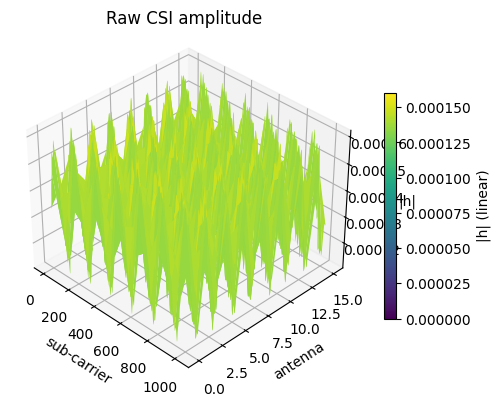

In [54]:
###########################################################################
#  Pick ONE link
###########################################################################
rx_link = h[0,                 # batch
                 :,                # all 16 Rx antennas
                 0,                # first Tx in your scene
                 0,                # first Tx antenna
                 0, :]             # time dim is size-1, all sub-c
# rx_link.shape → (16, 1024)

h_mag = np.abs(rx_link)             # (ant , subc)

###########################################################################
#  3-D surface  (identical to the paper’s “dense” picture)
###########################################################################
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401
import matplotlib.pyplot as plt, numpy as np

ant_idx = np.arange(h_mag.shape[0])       # 0 … 15
sub_idx = np.arange(h_mag.shape[1])       # 0 … 1023
X, Y    = np.meshgrid(sub_idx, ant_idx)

fig = plt.figure(figsize=(6,4))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, h_mag,
                       cmap='viridis', edgecolor='none',
                       vmin=0,
                       vmax=np.percentile(h_mag, 99.5))   # keep LoS visible
fig.colorbar(surf, shrink=0.65, label='|h| (linear)')
ax.set_xlabel('sub-carrier');  ax.set_ylabel('antenna')
ax.set_zlabel('|h|')
ax.set_title('Raw CSI amplitude')
ax.view_init(elev=35, azim=-45)
plt.tight_layout();  plt.show()


In [55]:
# ---- reshape correctly (4 cols × 4 rows) -------------------------------
H = tf.reshape(rx_link, (4, 4, -1))      # (col , row , F)
H = tf.transpose(H, [2, 1, 0])           # (F , row , col)

# ---- spatial FFT  ------------------------------------------------------
H_ang = tf.signal.fftshift(tf.signal.fft2d(H), axes=(1,2))

# ---- freq → delay ------------------------------------------------------
H_ang = tf.transpose(H_ang, [1,2,0])     # put F last
h_tau = tf.signal.ifft(H_ang)            # (row , col , delay)

P_db  = 10*np.log10(np.abs(h_tau)**2 + 1e-12)   # dB

# ---- axes --------------------------------------------------------------
fc, c0 = 3.5e9, 299_792_458.
lam = c0/fc
dx = dy = 0.5*lam
BW = 1024*30e3

az_deg = np.degrees(np.arcsin(np.linspace(-1,1,4)*lam/(2*dx)))
el_deg = np.degrees(np.arcsin(np.linspace(-1,1,4)*lam/(2*dy)))
taus_ns= np.arange(P_db.shape[2]) / BW * 1e9   # ns



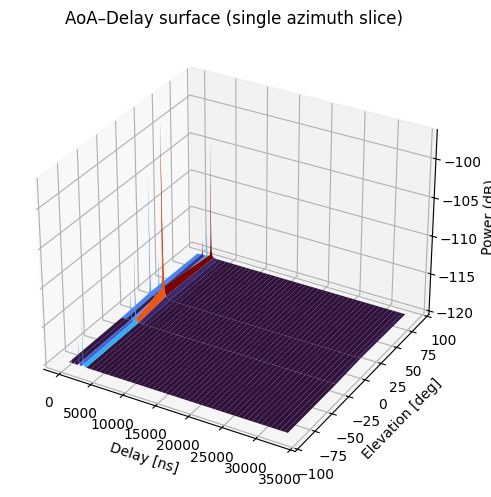

In [59]:
from mpl_toolkits.mplot3d import Axes3D
X, Y = np.meshgrid(taus_ns, el_deg)
Z    = P_db[:, az_idx, :]    # shape (El , Delay)

fig = plt.figure(figsize=(7,5))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='turbo', edgecolor='none')
ax.set_xlabel('Delay [ns]');  ax.set_ylabel('Elevation [deg]')
ax.set_zlabel('Power (dB)')
ax.set_title('AoA–Delay surface (single azimuth slice)')
plt.tight_layout();  plt.show()




In [65]:
import numpy as np, pandas as pd
a, tau = paths.cir(normalize_delays=False, out_type="numpy")
a_sel      = a  [0, 0, 0, 0, :, 0]
tau_ns     = tau[0, 0, 0, 0, :] / 1e-9
Zenith_deg    = np.degrees(paths.theta_r.numpy()[0,0,0,0,:])#Zenith angles of arrival [rad]
phi_deg    = np.degrees(paths.phi_r.numpy()[0,0,0,0,:]) #Azimuth angles of arrival
pow_lin    = np.abs(a_sel)**2
# ---- pull the six paths for Rx ant 0, Tx ant 0 ----


pow_lin = np.abs(a_sel)**2
pow_db  = 10*np.log10(pow_lin + 1e-30)

tbl = pd.DataFrame({
        'Path #': np.arange(len(a_sel)),
        'Delay (ns)': np.round(tau_ns,   1),
        'Azimuth (deg)': np.round(phi_deg,1),
        'Zenith (deg)': np.round(Zenith_deg,1),
        'Power (dB rel)': np.round(pow_db - pow_db.max(), 1)  # 0 dB = strongest
     })

print(tbl.to_string(index=False))


 Path #  Delay (ns)  Azimuth (deg)  Zenith (deg)  Power (dB rel)
      0  865.200012     160.100006    112.699997      -54.500000
      1 1657.800049     173.399994    101.599998      -51.200001
      2  166.800003     180.000000     90.000000        0.000000
      3  373.299988     180.000000    153.500000      -15.900000
      4 2268.800049     -44.799999     98.500000      -38.500000
      5 1572.300049     -83.500000     98.300003      -39.700001


In [70]:
# ------------ 1. reshape (col,row,F) & shift frequency axis -------------
H = tf.reshape(rx_link, (4, 4, -1))          # (col,row,F)
H = tf.transpose(H, [2, 1, 0])               # (F,row,col)
H = tf.signal.fftshift(H, axes=0)            # <<< centre DC before IFFT

# ------------ 2. spatial FFT then IFFT over freq -> delay ---------------
H_ang = tf.signal.fftshift(tf.signal.fft2d(H), axes=(1,2))
h_tau = tf.signal.ifft(tf.transpose(H_ang, [1,2,0]))        # (row,col,delay)
P_db  = 10*np.log10(np.abs(h_tau)**2 + 1e-12)

# ------------ 3. build physical axes exactly once -----------------------
BW = num_subcarriers * subcarrier_spacing      # 30.72 MHz
taus_ns = np.arange(P_db.shape[2]) / BW * 1e9

fc, c0 = 3.5e9, 299_792_458.
lam = c0/fc;  dx = dy = 0.5*lam
az_deg = np.degrees(np.arcsin(np.linspace(-1,1,4)*lam/(2*dx)))
el_deg = np.degrees(np.arcsin(np.linspace(-1,1,4)*lam/(2*dy)))

# ------------ 4. pick K strongest peaks ---------------------------------
K = 6
idx_flat = np.argpartition(P_db.ravel(), -K)[-K:]
rows, cols, delays = np.unravel_index(idx_flat, P_db.shape)

peaks = pd.DataFrame({
    'Delay (ns)'     : np.round(taus_ns[delays], 1),
    'Azimuth (deg)'  : np.round(az_deg[cols],   1),
    'Elevation (deg)': np.round(el_deg[rows],   1),
    'Power (dB)'     : np.round(P_db[rows, cols, delays], 1)
}).sort_values('Power (dB)', ascending=False)

print(peaks.to_string(index=False))




 Delay (ns)  Azimuth (deg)  Elevation (deg)  Power (dB)
      162.8           19.5             19.5  -53.400002
      195.3           19.5             19.5  -70.400002
      130.2           19.5             19.5  -72.599998
      358.1           19.5            -90.0  -73.099998
      390.6           19.5            -90.0  -74.400002
      227.9           19.5             19.5  -77.000000


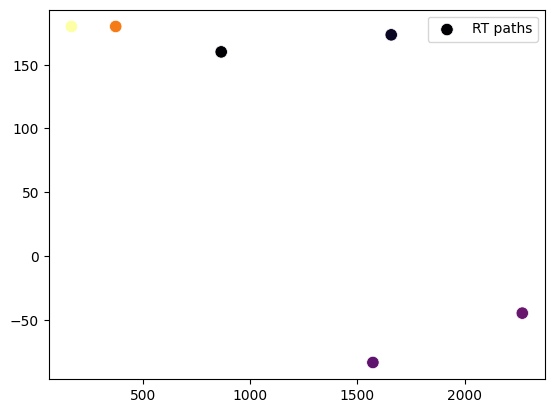

In [41]:
plt.scatter(tau_ns, phi_deg, s=80,
            c=pow_db, cmap='inferno', edgecolor='white', linewidth=0.5,
            label='RT paths')
plt.legend(); plt.show()
